In [4]:
import os

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pytorch_lightning as pl

# Tarefa 0: Exploração dos dados

Conforme consta na descrição do dataset, pude verificar que, para cada efeito implementado por um estudante, há uma pasta que identifica esse estudante e esse efeito, na qual encontram-se todas as imagens enviadas pelos alunos após passaram pelo efeito em questão.

Algo que me preocupava e que pude verificar de imediato, é que as imagens possuem tamanhos diferentes. Desse modo, a não ser que meu modelo seja fully convolutional, terei que encontrar alguma forma de padronizar os tamanhos.

Outra coisa que me chamou a atenção é a quantidade de categorias que os modelos de aprendizado supervisonado terão que aprender:

In [5]:
root, dirs, files = next(os.walk("photos/dataset"))
print(f"Número total de efeitos: {len(dirs)}")

Número total de efeitos: 42


<br><br>

Outro ponto que me chamou a atenção é a quantidade de "clusters" de efeitos similares (ou até iguais) uns aos outros. Por exemplo, vendo apenas a quantidade de efeitos com "edge" ou "borda" no nome, temos:

In [6]:
count = 0
for root, dirs, files in os.walk("photos/dataset"):
    for dir in dirs:
        if "edge" in dir or "borda" in dir:
            count += 1

print(f"Número total de efeitos de borda: {count}")

Número total de efeitos de borda: 6


Também pude perceber que há efeitos que acabaram deixando as imagens muito próximas das imagens originais (há, até mesmo, um efeito identidade, que aparenta não fazer nada!). Bom, esses pontos sugerem duas coisas: 
1. Talvez será possível visualizar esses clusters pelos modelos de aprendizado não supervisionado;
2. Provavelmente os modelos de classficação irão se confundir entre amostras desses clusters de efeitos similares, 

<br><br>

Por fim, também pude perceber que há efeitos "mis-nomeados" (ou que, pelo menos, não se aplicaram bem às imagens). Por exemplo, o efeito `245760_aberracao_cromatica` parece apenas transformar a maiorias das imagens para grayscale.

# Data Loading & Preprocessing

## Carregamento de dados

In [7]:
class FotosDaFEEC_Dataset(Dataset):
    def __init__(self, dataset_folder_path: str, debug: bool = False, transform=None):
        self.dataset_folder_path = dataset_folder_path
        self.debug = debug
        self.transform = transform

        # Get all classes and create a mapping from string to integers
        self.classes = sorted([d for d in os.listdir(dataset_folder_path) if os.path.isdir(os.path.join(dataset_folder_path, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # Recursively find all .jpg files in the directory
        self.file_paths = []
        for root, dir, files in os.walk(dataset_folder_path):
            for file in files:
                if file.endswith('.jpg'):
                    self.file_paths.append(os.path.join(root, file))
        
        self.cache = {}
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        if self.debug:
            print(f"Carregando imagem: {self.file_paths[idx]}")

        if idx in self.cache:
            img = self.cache[idx]
        else:
            with open(self.file_paths[idx], 'rb') as f:
                img = mpimg.imread(f)
            self.cache[idx] = img
        
        if self.transform:
            img = self.transform(img)

        effect_name = self.file_paths[idx].split("/")[-2]
        label = self.class_to_idx[effect_name]

        return img, label

### Testando dataset

Número total de amostras: 7686
Exemplo de amostra:
Carregando imagem: photos/dataset/245760_deteccao_borda/241163_labs.jpg


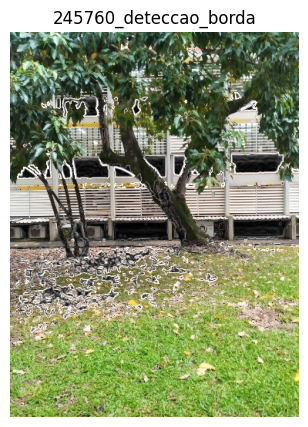

In [8]:
dataset_dummy = FotosDaFEEC_Dataset("photos/dataset", debug=True)
print(f"Número total de amostras: {len(dataset_dummy)}")

print("Exemplo de amostra:")
# Now returns the integer label instead of string
img, label = dataset_dummy[42]
plt.figure(figsize=(5, 5))
plt.imshow(img)
# Map it back to the string using the dataset's classes attribute for the title
plt.title(dataset_dummy.classes[label])
plt.axis('off')
plt.show()

#### Testando aplicação de transformações

In [9]:
dataset_dummy = FotosDaFEEC_Dataset("photos/dataset", transform=transforms.ToTensor())
sample = dataset_dummy[42]
print(f"Tipo da imagem: {sample[0].dtype}")
print(f"Shape da imagem: {sample[0].shape}")
display(sample[0])

Tipo da imagem: torch.float32
Shape da imagem: torch.Size([3, 500, 375])


/home/everton/Development/EA979/2026s1-projetopi-e2-Everton-Colombo/venv/lib/python3.10/site-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


tensor([[[0.2745, 0.3137, 0.4863,  ..., 0.4471, 0.4510, 0.5569],
         [0.2824, 0.3490, 0.3020,  ..., 0.4157, 0.5020, 0.4941],
         [0.2549, 0.2510, 0.3451,  ..., 0.4118, 0.4706, 0.3333],
         ...,
         [0.6235, 0.6941, 0.6941,  ..., 0.6275, 0.6353, 0.6902],
         [0.6471, 0.5765, 0.6000,  ..., 0.4392, 0.6157, 0.7333],
         [0.5137, 0.5922, 0.5294,  ..., 0.6314, 0.4706, 0.6471]],

        [[0.4314, 0.4706, 0.6431,  ..., 0.5922, 0.5922, 0.7098],
         [0.4314, 0.4980, 0.4471,  ..., 0.5569, 0.6549, 0.6431],
         [0.3961, 0.3922, 0.4824,  ..., 0.5647, 0.6275, 0.4863],
         ...,
         [0.6745, 0.7451, 0.7412,  ..., 0.7098, 0.7098, 0.7529],
         [0.6863, 0.6275, 0.6471,  ..., 0.5020, 0.6745, 0.7804],
         [0.5529, 0.6314, 0.5765,  ..., 0.6902, 0.5216, 0.6902]],

        [[0.3882, 0.4353, 0.6118,  ..., 0.4706, 0.4824, 0.6039],
         [0.3882, 0.4549, 0.4196,  ..., 0.4471, 0.5490, 0.5451],
         [0.3490, 0.3529, 0.4549,  ..., 0.4588, 0.5255, 0.

## Pré-processamento

Como as imagens possuem tamnhos diferentes, poderíamos ou fazer com que o modelo fosse uma FCN, ou encontrar uma maneira de fazer com que todas elas tenham o mesmo tamanho. Como não quero ter a dor de cabeça ao fazer o stack das imagens durante o processo de batching, vou apenas seguir com a segunda opção.

Minha ideia inicial é verificar qual é o tamanho do maior retângulo que caberia em todas as imagens e aplicar crop com esse tamanho.

In [10]:
min_x, min_y = float('inf'), float('inf')
max_x, max_y = float('-inf'), float('-inf')

for img, _ in dataset_dummy:
    min_x = min(img.shape[1], min_x)
    max_x = max(img.shape[1], max_x)
    min_y = min(img.shape[2], min_y)
    max_y = max(img.shape[2], max_y)

print(f"Menor largura (x): {min_x}")
print(f"Menor altura (y): {min_y}")
print()
print(f"Maior largura (x): {max_x}")
print(f"Maior altura (y): {max_y}")

Menor largura (x): 280
Menor altura (y): 228

Maior largura (x): 500
Maior altura (y): 500


In [11]:
thrown_away_percentages = np.zeros((len(dataset_dummy),))
for i, (img, _) in enumerate(dataset_dummy):
    total_pixels = img.shape[1] * img.shape[2]
    thrown_away_pixels = (img.shape[1] - min_x) * img.shape[2] + (img.shape[2] - min_y) * img.shape[1] - (img.shape[1] - min_x) * (img.shape[2] - min_y)
    thrown_away_percentages[i] = thrown_away_pixels / total_pixels

print(f"Porcentagem média de pixels descartados: {thrown_away_percentages.mean() * 100:.2f}%")

Porcentagem média de pixels descartados: 63.51%


Ok, então se eu quisesse apenas recortar de todas imagens um retângulo de um tamanho máximo que coubesse em todas elas, esse tamanho deve ser de (280, 228). Legal, entretanto se eu apenas fizer isso, estarei jogando fora **63.51%** dos pixels. Me parece muita informação para descartar..

Para corrigir isso, ao invés de apenas aplicar `transforms.CenterCrop()`, vou aplicar `transforms.RandomCrop()`, que recorta um triângulo aleatório da imagem cada vez que a imagem é carregada, aumentando a chance do modelo ver uma maior parte dos pixels de uma mesma imagem durante o treinamento.

De imediato, isso me faz pensar que efeitos aplicam artefatos em regiões específicas da imagem, como vignettes e pixelação localizada, podem acabar sendo mais difíceis de aprender, já que o modelo pode não ver essas regiões específicas em todas as imagens durante o treinamento.

***

In [12]:
complete_dataset = FotosDaFEEC_Dataset("photos/dataset", transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomCrop((min_x, min_y))
]))

In [13]:
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(complete_dataset, [0.7, 0.15, 0.15], generator=torch.Generator().manual_seed(42))

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Algoritmos de aprendizado supervisionado

Para a tarefa de classificação, vou testar três CNNs diferentes:
1. EffNet (torchvision.models.efficientnet_b0);
2. ResNet (torchvision.models.resnet18);
3. Uma CNN simples, que criei do zero, contendo 3 blocos de convolução + ReLU + MaxPool, seguidos por um bloco de classificação com 1 camada linear + ReLU + Dropout + camada linear final.
***

In [14]:
import torchvision
from torchmetrics import Accuracy
from torch.optim import AdamW

from pytorch_lightning.loggers import TensorBoardLogger

import multiprocessing as mp

from pytorch_lightning.callbacks import ModelCheckpoint

%load_ext tensorboard

### EffNet:
Tive apenas que substituir a última camada linear da EffNet para que ela tivesse 42 saídas, correspondentes às 42 categorias de efeitos presentes no dataset.

In [15]:
class EffNetFotosFeec(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model: nn.Module = torchvision.models.efficientnet_b0(weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT)
        self.model.classifier[1] = nn.Linear(in_features=1280, out_features=42, bias=True)
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=42)

    def forward(self, x):
        return self.model(x)
    
    def classification_step(self, mode, batch):
        x, y = batch
        logits = self.forward(x)
        loss = self.loss(logits, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            preds = torch.argmax(logits, dim=1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)
        
    def training_step(self, train_batch):
        return self.classification_step("train", train_batch)
    
    def validation_step(self, val_batch):
        self.classification_step("val", val_batch)
    
    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)
        return optimizer

In [13]:
hparams = {
    "experiment_name": "EffNet",
    "max_epochs": 20,
    "nworkers": mp.cpu_count() // 2,
    "lr": 1e-4,
    "wd": 1e-5,
    "cpu": False,
}

model = EffNetFotosFeec(hparams)

tb_logger = TensorBoardLogger(save_dir="tb_logs", name=hparams["experiment_name"])

checkpoint_callback = [ModelCheckpoint(
    filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
    monitor="val_acc",
    mode="max"
)]

trainer = pl.Trainer(
    max_epochs=hparams["max_epochs"],
    callbacks=checkpoint_callback,
    logger=tb_logger,
    log_every_n_steps=1
)

trainer.fit(model, train_dataloader, val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 6GB Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type               | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model    | EfficientNet       | 4.1 M  | train | 0    
1 | loss     | CrossEntropyLoss   | 0      | train | 0    
2 | accuracy | MulticlassA

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/everton/Development/EA979/2026s1-projetopi-e2-Everton-Colombo/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/everton/Development/EA979/2026s1-projetopi-e2-Everton-Colombo/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


/home/everton/Development/EA979/2026s1-projetopi-e2-Everton-Colombo/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 19: 100%|██████████| 169/169 [00:52<00:00,  3.25it/s, v_num=0, val_loss=0.247, val_acc=0.900]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 169/169 [00:52<00:00,  3.25it/s, v_num=0, val_loss=0.247, val_acc=0.900]


### ResNet:
Assim como na EffNet, tive apenas que substituir a última camada linear da ResNet para que ela tivesse 42 saídas, correspondentes às 42 categorias de efeitos presentes no dataset.

In [16]:
class ResNetFotosFeec(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)
        
        self.model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
        self.model.fc = nn.Linear(in_features=self.model.fc.in_features, out_features=42, bias=True)
        
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=42)

    def forward(self, x):
        return self.model(x)
    
    def classification_step(self, mode, batch):
        x, y = batch
        logits = self.forward(x)
        loss = self.loss(logits, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            preds = torch.argmax(logits, dim=1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)
        
    def training_step(self, train_batch):
        return self.classification_step("train", train_batch)
    
    def validation_step(self, val_batch):
        self.classification_step("val", val_batch)
    
    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)
        return optimizer

In [15]:
hparams_resnet = {
    "experiment_name": "ResNet18",
    "max_epochs": 20,
    "nworkers": mp.cpu_count() // 2,
    "lr": 1e-4,
    "wd": 1e-5,
    "cpu": False,
}

model_resnet = ResNetFotosFeec(hparams_resnet)

tb_logger_resnet = TensorBoardLogger(save_dir="tb_logs", name=hparams_resnet["experiment_name"])

checkpoint_callback_resnet = [ModelCheckpoint(
    filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
    monitor="val_acc",
    mode="max"
)]

trainer_resnet = pl.Trainer(
    max_epochs=hparams_resnet["max_epochs"],
    callbacks=checkpoint_callback_resnet,
    logger=tb_logger_resnet,
    log_every_n_steps=1
)

trainer_resnet.fit(model_resnet, train_dataloader, val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type               | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model    | ResNet             | 11.2 M | train | 0    
1 | loss     | CrossEntropyLoss   | 0      | train | 0    
2 | accuracy | MulticlassAccuracy | 0      | train | 0    
----------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.792    Total estimated model params size (MB)
70        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 19: 100%|██████████| 169/169 [00:31<00:00,  5.45it/s, v_num=0, val_loss=0.319, val_acc=0.871]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 169/169 [00:31<00:00,  5.45it/s, v_num=0, val_loss=0.319, val_acc=0.871]


### CNN Simples:

Utilizei uma estrutura "clássica", composta por uma série de blocos de `Conv2d`, acompanhados por ativação `ReLU` e `MaxPool2d`. As camadas densas de classificação, por sua vez, são compostas por uma camada linear, seguida por `ReLU`, `Dropout` e a camada linear final, que tem 42 saídas, correspondentes às 42 categorias de efeitos presentes no dataset.

In [17]:
class SimpleCNNFotosFeec(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)
        
        self.features = nn.Sequential(
            # Bloco 1
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            # Bloco 2
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            # Bloco 3
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 42)
        )
        
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=42)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
    def classification_step(self, mode, batch):
        x, y = batch
        logits = self.forward(x)
        loss = self.loss(logits, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            preds = torch.argmax(logits, dim=1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)
        
    def training_step(self, train_batch):
        return self.classification_step("train", train_batch)
    
    def validation_step(self, val_batch):
        self.classification_step("val", val_batch)
    
    def configure_optimizers(self):
        optimizer = AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)
        return optimizer

In [17]:
hparams_simple_cnn = {
    "experiment_name": "SimpleCNN",
    "max_epochs": 50,
    "nworkers": mp.cpu_count() // 2,
    "lr": 1e-4,
    "wd": 1e-5,
    "cpu": False,
}

model_simple_cnn = SimpleCNNFotosFeec(hparams_simple_cnn)

tb_logger_simple_cnn = TensorBoardLogger(save_dir="tb_logs", name=hparams_simple_cnn["experiment_name"])

checkpoint_callback_simple_cnn = [ModelCheckpoint(
    filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
    monitor="val_acc",
    mode="max"
)]

trainer_simple_cnn = pl.Trainer(
    max_epochs=hparams_simple_cnn["max_epochs"],
    callbacks=checkpoint_callback_simple_cnn,
    logger=tb_logger_simple_cnn,
    log_every_n_steps=1
)

trainer_simple_cnn.fit(model_simple_cnn, train_dataloader, val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type               | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | features   | Sequential         | 23.6 K | train | 0    
1 | classifier | Sequential         | 13.7 K | train | 0    
2 | loss       | CrossEntropyLoss   | 0      | train | 0    
3 | accuracy   | MulticlassAccuracy | 0      | train | 0    
------------------------------------------------------------------
37.3 K    Trainable params
0         Non-trainable params
37.3 K    Total params
0.149     Total estimated model params size (MB)
19        Modules in train mode
0         Modules in eval mode
0         Total

Epoch 49: 100%|██████████| 169/169 [00:10<00:00, 15.78it/s, v_num=0, val_loss=1.940, val_acc=0.408]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 169/169 [00:10<00:00, 15.77it/s, v_num=0, val_loss=1.940, val_acc=0.408]


***
## Resultados

In [19]:
%tensorboard --logdir tb_logs

Reusing TensorBoard on port 6006 (pid 45446), started 0:00:07 ago. (Use '!kill 45446' to kill it.)

Os resultados, mostrados no tensorboard acima, mostram que a EffNet foi o modelo com melhor desempenho, com uma val_acc = 0.91. Em segundo lugar, encontra-se a Resnet, com val_acc = 0.88. A CNN simples, por sua vez, teve um desempenho bem inferior, com val_acc = 0.41.

#### Verificando algumas predições dos modelos:

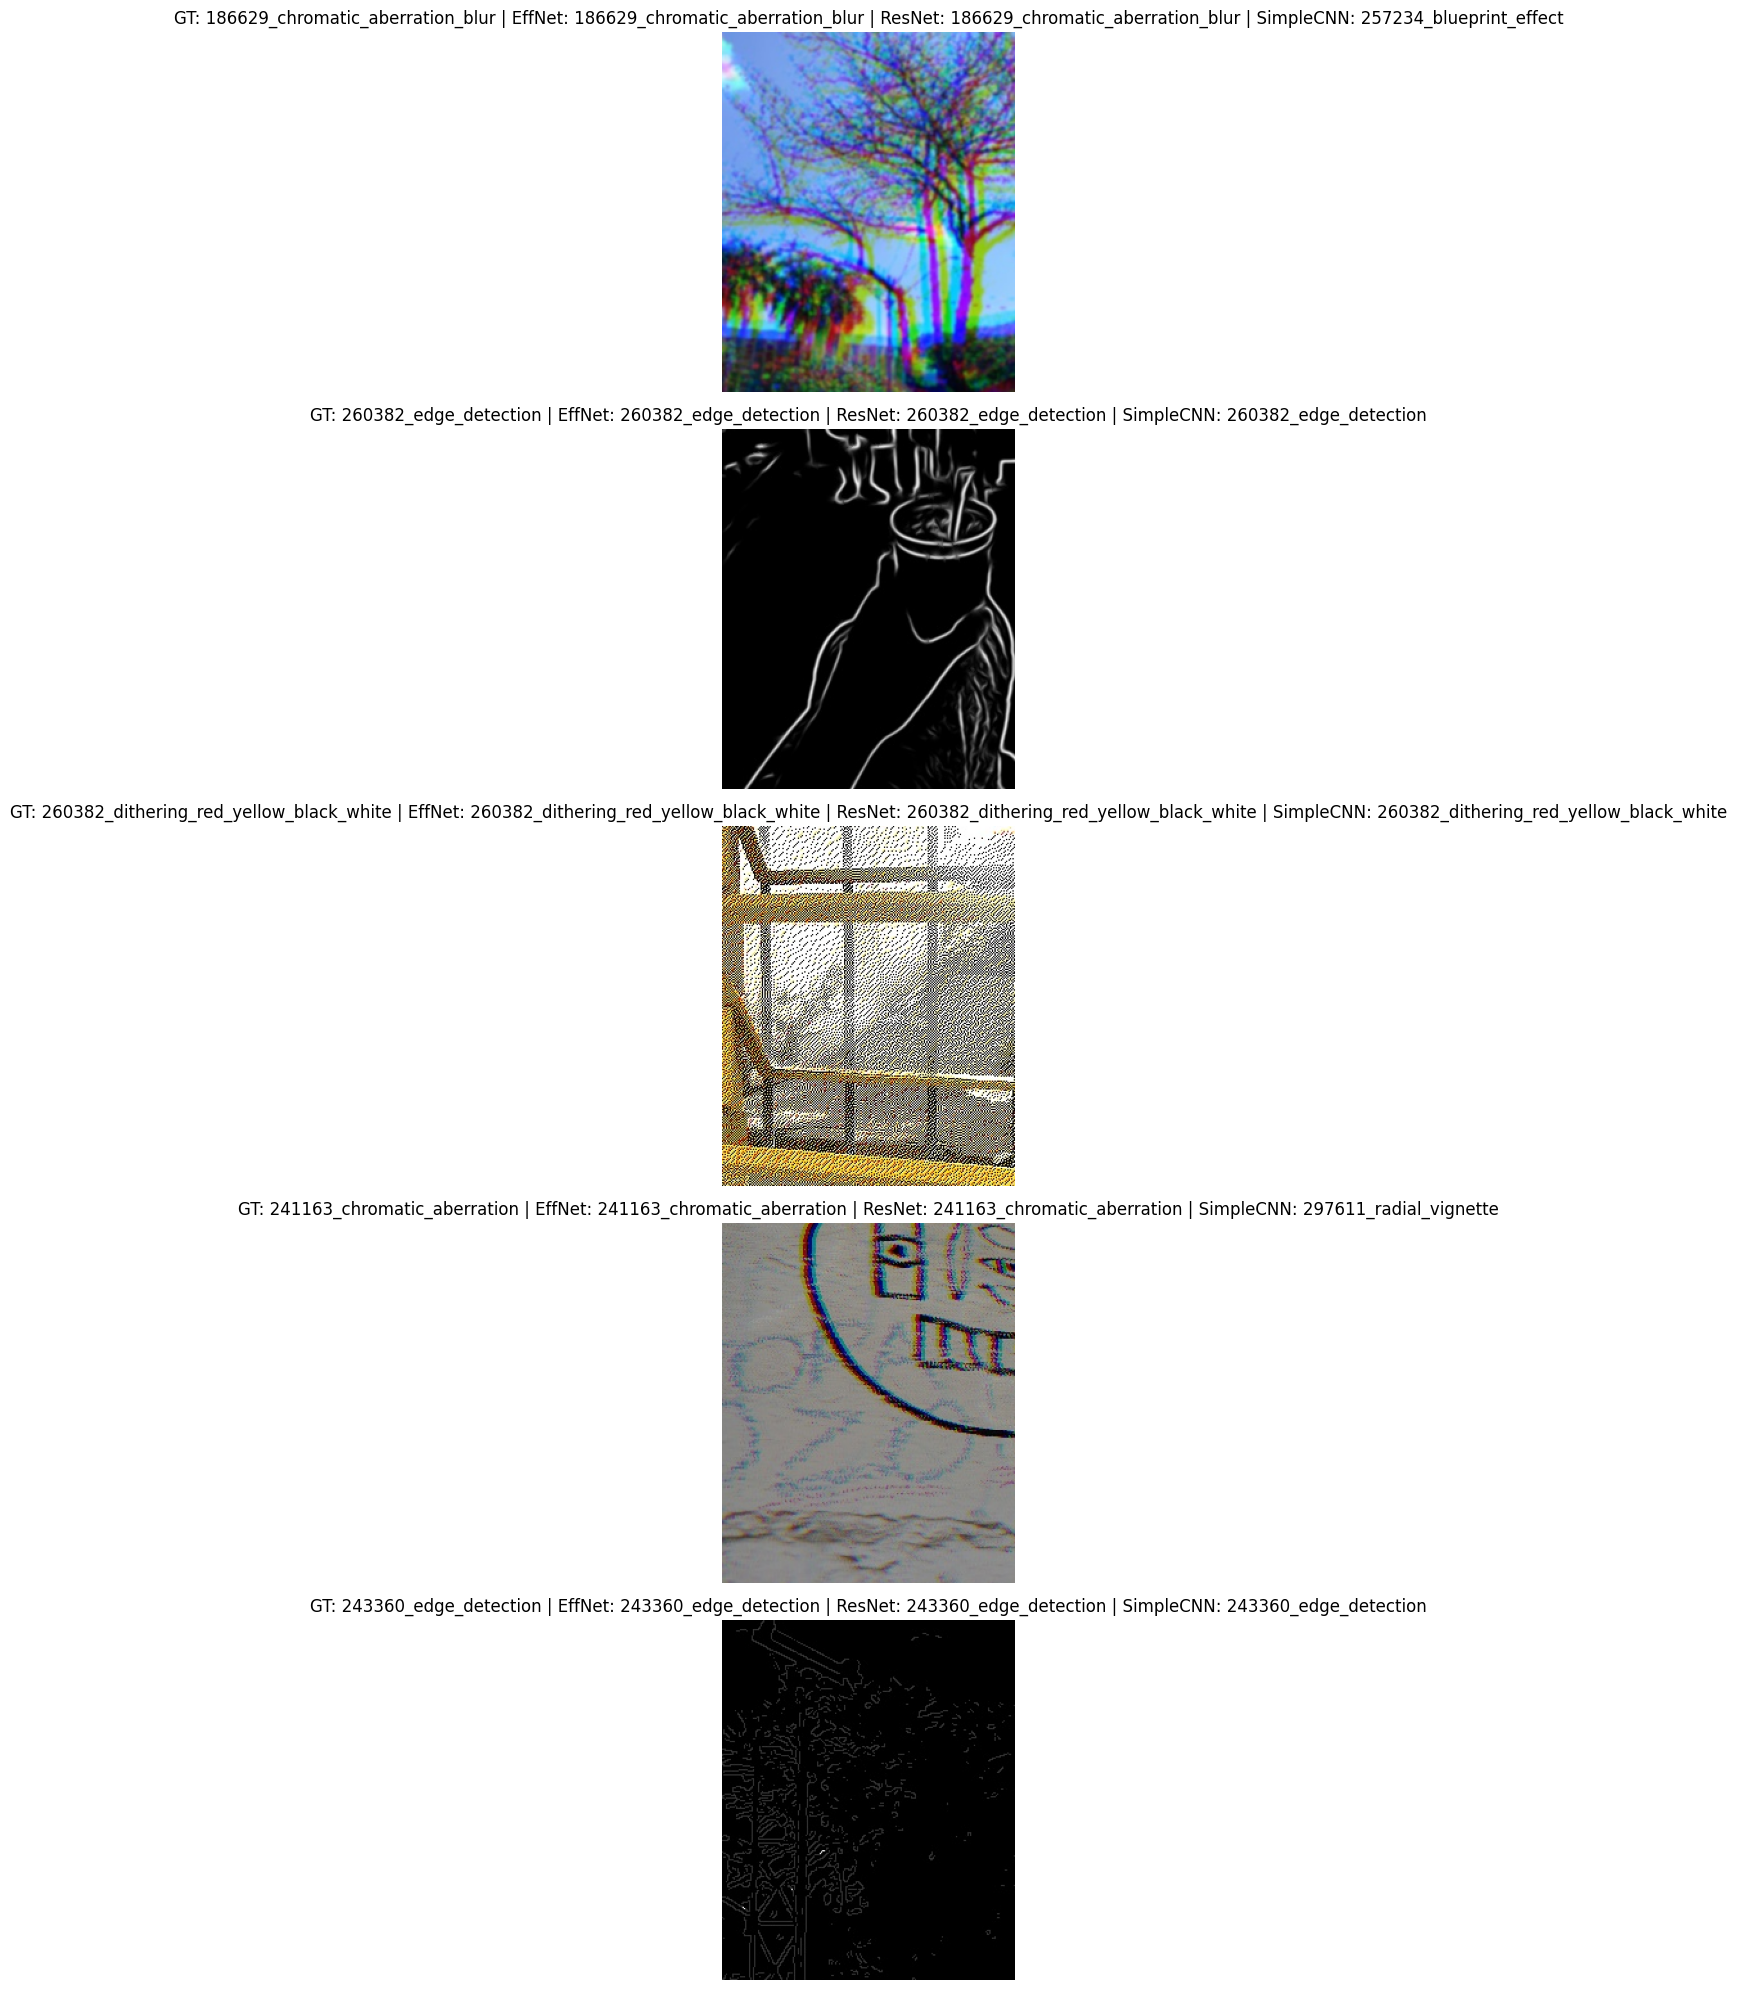

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

effnet_model = EffNetFotosFeec.load_from_checkpoint("tb_logs/EffNet/version_0/checkpoints/EffNet-epoch=16-val_acc=0.91.ckpt")
effnet_model.eval().to(device)

resnet_model = ResNetFotosFeec.load_from_checkpoint("tb_logs/ResNet18/version_0/checkpoints/EffNet-epoch=9-val_acc=0.88.ckpt")
resnet_model.eval().to(device)

simple_cnn_model = SimpleCNNFotosFeec.load_from_checkpoint("tb_logs/SimpleCNN/version_0/checkpoints/EffNet-epoch=49-val_acc=0.41.ckpt")
simple_cnn_model.eval().to(device)

n_samples = 5
fig, axes = plt.subplots(n_samples, 1, figsize=(12, 4 * n_samples))

with torch.no_grad():
    for ax, idx in zip(axes, range(n_samples)):
        x, y = val_dataset[idx]
        x_input = x.unsqueeze(0).to(device)

        pred_effnet = effnet_model(x_input).argmax(dim=1).item()
        pred_resnet = resnet_model(x_input).argmax(dim=1).item()
        pred_simple = simple_cnn_model(x_input).argmax(dim=1).item()

        ax.imshow(x.permute(1, 2, 0).cpu())
        ax.axis("off")
        ax.set_title(
            f"GT: {complete_dataset.classes[y]} | "
            f"EffNet: {complete_dataset.classes[pred_effnet]} | "
            f"ResNet: {complete_dataset.classes[pred_resnet]} | "
            f"SimpleCNN: {complete_dataset.classes[pred_simple]}"
        )

plt.tight_layout()
plt.show()

### Métricas

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

#### Métricas de performace

In [ ]:
all_preds_effnet = []
all_preds_resnet = []
all_preds_simple = []
all_labels = []

with torch.no_grad():
    for x, y in val_dataloader:
        x = x.to('cuda')
        
        preds_eff = effnet_model(x).argmax(dim=1)
        preds_res = resnet_model(x).argmax(dim=1)
        preds_sim = simple_cnn_model(x).argmax(dim=1)
        
        all_preds_effnet.extend(preds_eff.cpu().numpy())
        all_preds_resnet.extend(preds_res.cpu().numpy())
        all_preds_simple.extend(preds_sim.cpu().numpy())
        all_labels.extend(y.numpy())

models_preds = {
    'EffNet': all_preds_effnet,
    'ResNet18': all_preds_resnet,
    'SimpleCNN': all_preds_simple
}


In [34]:
for model_name, preds in models_preds.items():
    print(f"--- {model_name} ---")
    print(f"Accuracy:\t\t{accuracy_score(all_labels, preds):.4f}")
    print(f"Precision (Macro):\t{precision_score(all_labels, preds, average='macro', zero_division=0):.4f}")
    print(f"Recall (Macro):\t\t{recall_score(all_labels, preds, average='macro', zero_division=0):.4f}")
    print(f"F1 Score (Macro):\t{f1_score(all_labels, preds, average='macro', zero_division=0):.4f}")
    print()

--- EffNet ---
Accuracy:		0.9072
Precision (Macro):	0.9187
Recall (Macro):		0.9157
F1 Score (Macro):	0.9142

--- ResNet18 ---
Accuracy:		0.8899
Precision (Macro):	0.9050
Recall (Macro):		0.8956
F1 Score (Macro):	0.8974

--- SimpleCNN ---
Accuracy:		0.3946
Precision (Macro):	0.3519
Recall (Macro):		0.3949
F1 Score (Macro):	0.3530



**Conclusão:** A CNN simples realmente parece simples demais para aprender a classificar os efeitos presentes no dataset, enquanto a EffNet e a ResNet parecem ser modelos adequados para essa tarefa. As métricas de um mesmo modelo parecem estar bem balanceadas entre si.

#### Matrizes de confusão:

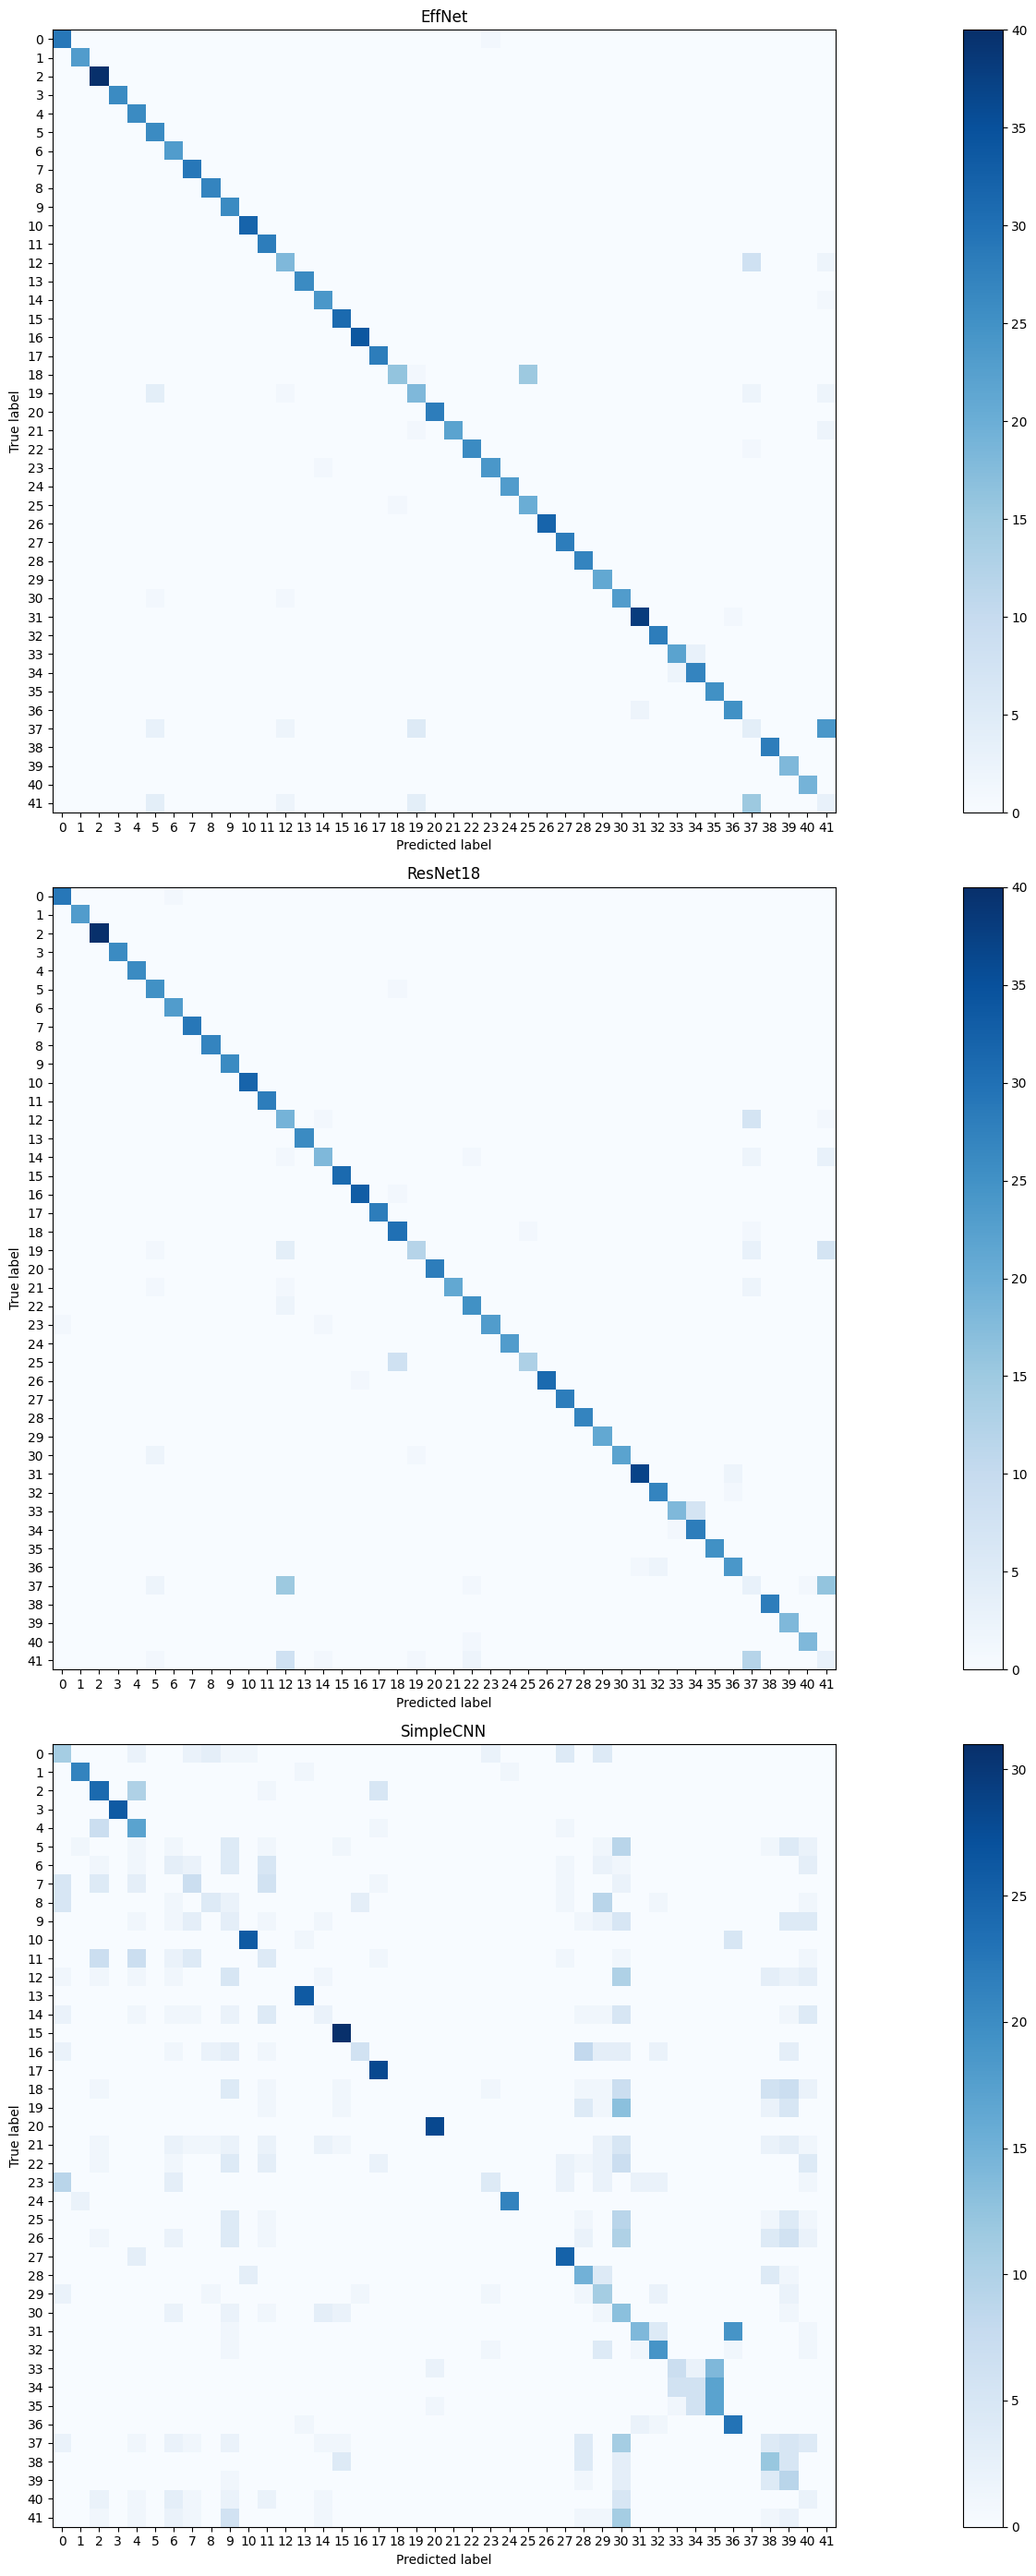

In [27]:
# Plotando as matrizes de confusão
fig, axes = plt.subplots(3, 1, figsize=(28, 28))

# Matriz EffNet
cm_eff = confusion_matrix(all_labels, all_preds_effnet)
disp_eff = ConfusionMatrixDisplay(cm_eff)
# include_values=False porque 42x42 classes ficará ilegível com números
disp_eff.plot(ax=axes[0], include_values=False, cmap='Blues', colorbar=True)
axes[0].set_title('EffNet')

# Matriz ResNet
cm_res = confusion_matrix(all_labels, all_preds_resnet)
disp_res = ConfusionMatrixDisplay(cm_res)
disp_res.plot(ax=axes[1], include_values=False, cmap='Blues', colorbar=True)
axes[1].set_title('ResNet18')

# Matriz SimpleCNN
cm_sim = confusion_matrix(all_labels, all_preds_simple)
disp_sim = ConfusionMatrixDisplay(cm_sim)
disp_sim.plot(ax=axes[2], include_values=False, cmap='Blues', colorbar=True)
axes[2].set_title('SimpleCNN')

plt.tight_layout()
plt.show()

Algumas analises interessantes das matrizes de confusão:

1. A effnet e a resnet parecem ter dificuldade em difirenciar entre as classes 37 e 41. Vejamos quais são os efeitos correspondentes a essas classes:

In [38]:
val_dataset.dataset.classes[37], val_dataset.dataset.classes[41]

('260382_effect_identity', 'origin')

São os efeitos identidade e a imagem original. De fato, essa confusão era esperada desde o início, pois são essencialmente a mesma imagem. Curiosamente, a CNN simples não parece confundir essas duas classes.

2. A effnet confunde bastante a classe 18 com a 25. Vejamos quais são:

In [39]:
val_dataset.dataset.classes[18], val_dataset.dataset.classes[25]

('245760_aberracao_cromatica', '247145_color_selection')

Esses dois efeitos parecem produzir várias imagens em escala de cinza, o que justifica a confusão entre eles.

3. A resnet confunde bastante a classe 37 com a 12. Vejamos quais são:

In [41]:
val_dataset.dataset.classes[37], val_dataset.dataset.classes[12]

('260382_effect_identity', '243360_chromatic_aberration')

Hmm, nesse caso os efeitos são facilmente distinguíveis para um humano.

***
# Algoritmos de aprendizado não supervisionado